In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch

from score.score import Score1d, Score2d
from score.distributions import (
	BrownianDiffusionJoint,
	standard_gaussian_1d,
	standard_gaussian_2d,
	symmetric_gaussian_mixture_1d,
)

In [2]:
mode_porp_raw = []

for _ in range(100):
    model = torch.nn.Sequential(
        torch.nn.Linear(1, 128),
        torch.nn.Softplus(),
        torch.nn.Linear(128, 128),
        torch.nn.Softplus(),
        torch.nn.Linear(128, 1))
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    score = Score1d(model, optimizer, symmetric_gaussian_mixture_1d())

    grad_norm = score.learn(
        n_samples_per_iter = 1000,
        n_iters = 500,
    )

    init_samples = standard_gaussian_1d().sample((1000, ))
    samples = score.sample_langevin(
        init_samples = init_samples,
        n_steps = 1000,
        epsilon = 0.1
    )

    mode_porp_raw.append((samples.squeeze() > 0).sum().item() / len(samples))

100%|██████████| 1000/1000 [00:00<00:00, 1661.28it/s]


(array([ 8., 10., 10., 21., 19., 10.,  6.,  8.,  6.,  2.]),
 array([0.442 , 0.4551, 0.4682, 0.4813, 0.4944, 0.5075, 0.5206, 0.5337,
        0.5468, 0.5599, 0.573 ]),
 <BarContainer object of 10 artists>)

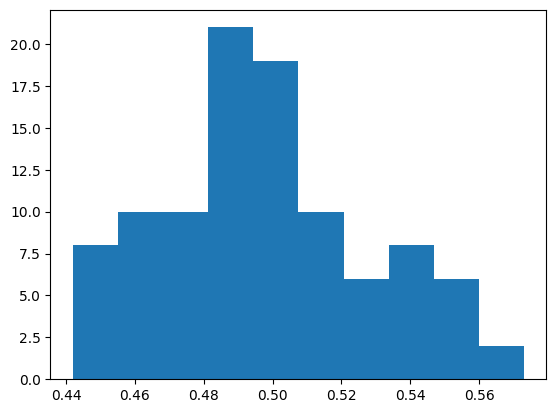

In [3]:
plt.hist(mode_porp_raw)

In [4]:
np.mean(mode_porp_raw), np.std(mode_porp_raw)

(0.4984700000000001, 0.02962446792771138)

In [5]:
mode_porp_pad, mode_prop_pad_slice = [], []

for _ in range(100):
	model = torch.nn.Sequential(
		torch.nn.Linear(2, 128),
		torch.nn.Softplus(),
		torch.nn.Linear(128, 128),
		torch.nn.Softplus(),
		torch.nn.Linear(128, 2))
	optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
	score = Score2d(
		model, 
		optimizer,
		BrownianDiffusionJoint(symmetric_gaussian_mixture_1d(), 4)
	)

	score.learn(
		n_samples_per_iter = 1000,
		n_iters = 500,
		keep_best = True 
	)

	init_samples = standard_gaussian_2d().sample((1000, ))
	samples = score.sample_langevin(
		init_samples = init_samples,
		n_steps = 1000,
		epsilon = 0.1
	)

	mode_porp_pad.append((samples.T[0] > 0).float().mean())
	mode_prop_pad_slice.append((
		samples.T[0][samples.T[1] < 1] > 0).float().mean())

100%|██████████| 1000/1000 [00:00<00:00, 1430.02it/s]


(array([ 5.,  2., 15., 11., 10., 13., 20., 17.,  5.,  2.]),
 array([0.35699999, 0.3845    , 0.412     , 0.4395    , 0.46700001,
        0.49450001, 0.52200001, 0.54949999, 0.57700002, 0.60450006,
        0.63200003]),
 <BarContainer object of 10 artists>)

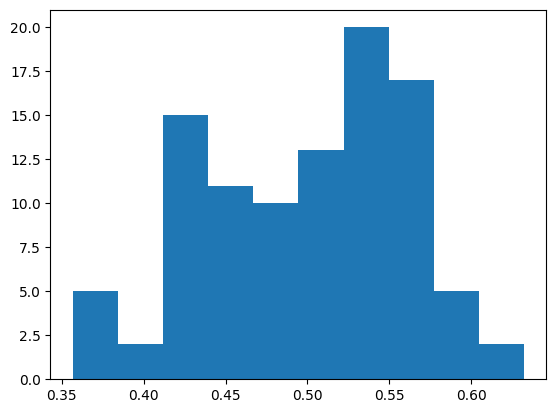

In [6]:
plt.hist(mode_porp_pad)

In [7]:
np.mean(mode_porp_pad), np.std(mode_porp_pad)

(0.49808, 0.06293198)

(array([ 1.,  3.,  9.,  9., 17., 21., 19., 15.,  3.,  3.]),
 array([0.28      , 0.32002032, 0.36004061, 0.40006089, 0.44008121,
        0.48010153, 0.52012181, 0.5601421 , 0.60016239, 0.64018273,
        0.68020302]),
 <BarContainer object of 10 artists>)

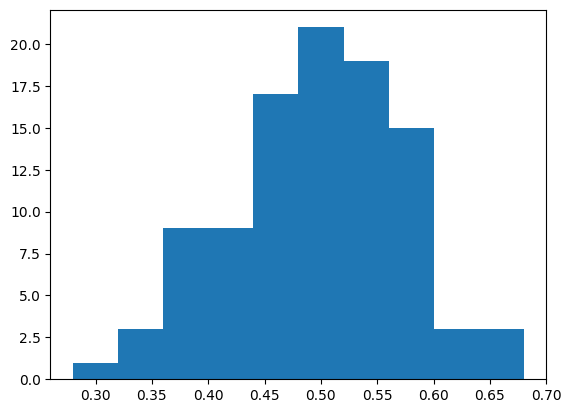

In [8]:
plt.hist(mode_prop_pad_slice)

In [9]:
np.mean(mode_prop_pad_slice), np.std(mode_prop_pad_slice)

(0.4966037, 0.076646596)